In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pytz

from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg

### 1. Preparing the data

In [10]:
df = pd.read_csv("Nairobi AirQuality.csv", sep=";", on_bad_lines="skip")
df.head()

,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,4930,pms5003,3981,-1.269,36.819,2025-12-01T00:00:00.931399+00:00,P2,22.60
1,4930,pms5003,3981,-1.269,36.819,2025-12-01T00:00:00.931399+00:00,P1,25.20
2,4930,pms5003,3981,-1.269,36.819,2025-12-01T00:00:00.931399+00:00,P0,15.00
3,4931,DHT22,3981,-1.269,36.819,2025-12-01T00:00:18.348581+00:00,humidity,73.60
4,4931,DHT22,3981,-1.269,36.819,2025-12-01T00:00:18.348581+00:00,temperature,18.10


I will be using a function for this one

In [80]:
def wrangle(filepath):

    #Load the data
    df = pd.read_csv(filepath, sep=";", on_bad_lines="skip")
    
    
    #Filter for PM2.5 readings only
    df = df[df["value_type"] == "P2"]
    
    #Parse timestamp and set as index
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, format='ISO8601')
    df = df.set_index("timestamp")
    
    #Keep only the PM2.5 value column
    df = df[["value"]]
    
    #Renaming
    df.columns = ["pm2.5"]
    
    #Sort by time
    df = df.sort_index()

    #Localize timezone
    df.index = df.index.tz_convert("Africa/Nairobi")

    #Convert to float, coerce bad values to NaN
    df["pm2.5"] = pd.to_numeric(df["pm2.5"], errors="coerce")

    #Removing outliers
    df = df[df["pm2.5"] < 500]

    #Resample to 1h window and ffill any missing values
    df = df["pm2.5"].resample("1h").mean().ffill().to_frame()

    #Add the lag feature
    df["pm2.5_L1"] = df["pm2.5"].shift(1)

    #Drop NaN  rows
    df.dropna(inplace=True)
    
    return df

In [81]:
df = wrangle("Nairobi AirQuality.csv")
df.head()

,pm2.5,pm2.5_L1
timestamp,,
2025-12-01 04:00:00+03:00,18.820000,24.144906
2025-12-01 05:00:00+03:00,28.562500,18.820000
2025-12-01 06:00:00+03:00,34.902381,28.562500
2025-12-01 07:00:00+03:00,32.240385,34.902381
2025-12-01 08:00:00+03:00,24.078571,32.240385


In [26]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 30884 entries, 2025-12-01 03:00:00.931399+03:00 to 2026-01-01 02:59:28.916949+03:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pm2.5   30877 non-null  float64
dtypes: float64(1)
memory usage: 482.6 KB


In [60]:
df.shape

(744, 1)

The timestamps are stored in Universal Coordinated Timer(UTC) so I localized them to the Nairobi timezone

In [14]:
df.index[:5]

DatetimeIndex(['2025-12-01 00:00:00.931399+00:00',
                      '2025-12-01 00:02:01+00:00',
               '2025-12-01 00:02:26.384604+00:00',
                      '2025-12-01 00:05:26+00:00',
                      '2025-12-01 00:05:26+00:00'],
              dtype='datetime64[us, UTC]', name='timestamp', freq=None)

In [ ]:
#localizing
df.index.tz_convert("Africa/Nairobi")[:5]

DatetimeIndex(['2025-12-01 03:00:00.931399+03:00',
                      '2025-12-01 03:02:01+03:00',
               '2025-12-01 03:02:26.384604+03:00',
                      '2025-12-01 03:05:26+03:00',
                      '2025-12-01 03:05:26+03:00'],
              dtype='datetime64[us, Africa/Nairobi]', name='timestamp', freq=None)

### 2. Exploratory Data Analysis(EDA)

<Axes: title={'center': 'Distribution of PM2.5 Reaadings'}>

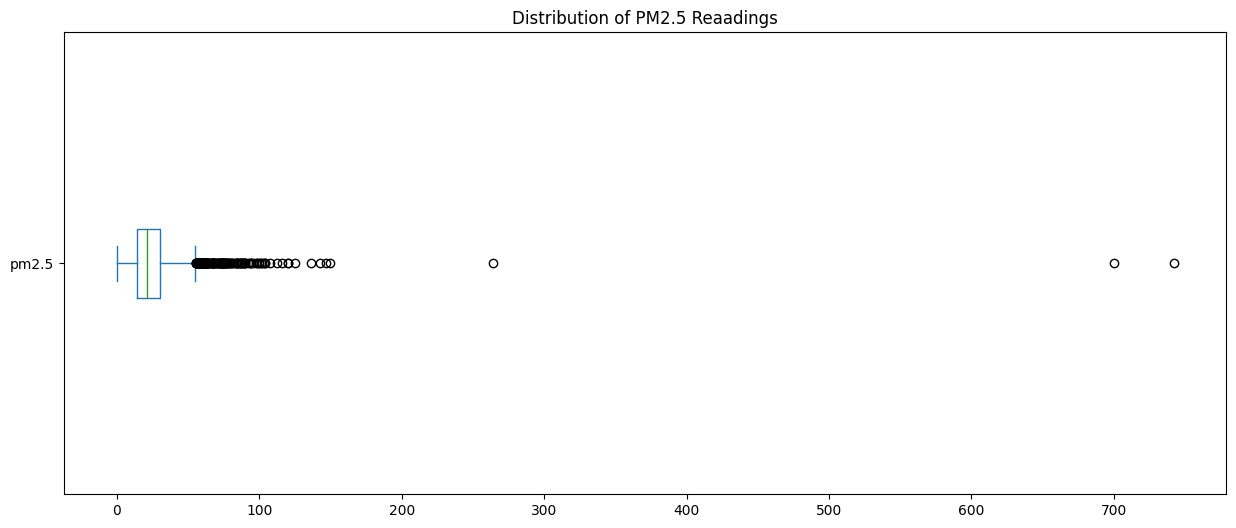

In [40]:
#I decided to check the distribution of PM2.5 readings to see if there are any outliers using a boxplot
fig, ax = plt.subplots(figsize=(15, 6))
df["pm2.5"].plot(kind="box", vert=False, title="Distribution of PM2.5 Reaadings", ax=ax)

After some research, the hazardous level readings are only up to around 500, so the figures above that are probably wrong

In [41]:
df = df[df["pm2.5"] < 500]

In [72]:
df.isna().sum()

pm2.5    0
dtype: int64

In [43]:
df.shape

(30875, 1)

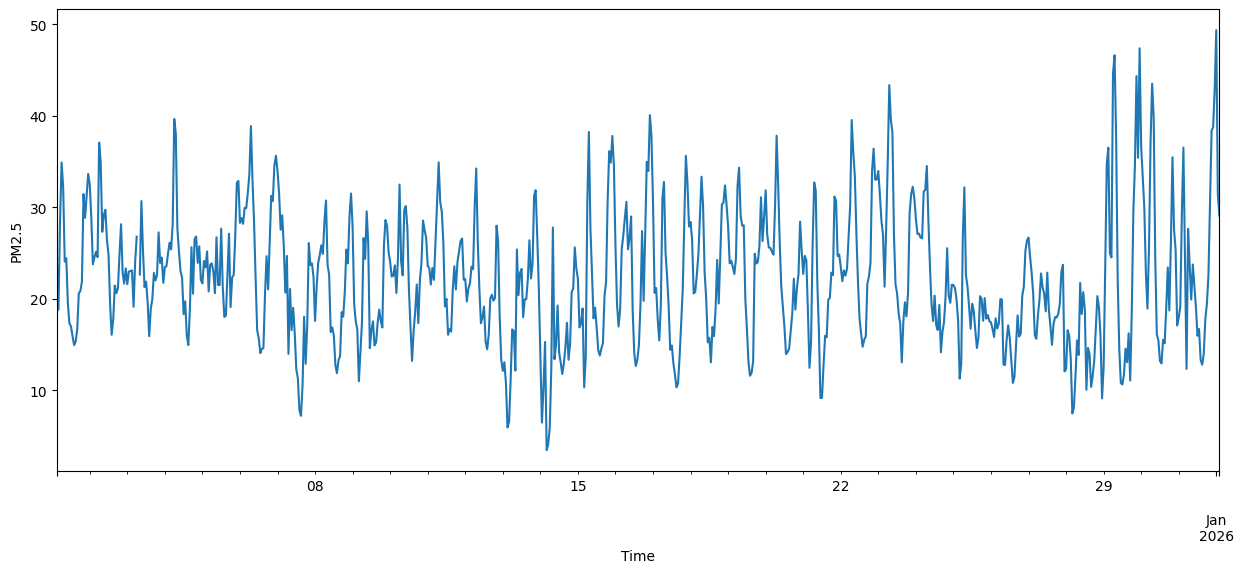

In [61]:
#Time Series line plot
fig, ax = plt.subplots(figsize=(15, 6))
df["pm2.5"].plot(xlabel="Time", ylabel="PM2.5", ax=ax);

There are no sudden breaks in the line plot which confirms no missing data.

In [ ]:
df["pm2.5"].resample("1h")

In [69]:
df = df["pm2.5"].resample("1h").mean().ffill().to_frame().head()

In [52]:
df.isna().sum()

pm2.5    0
dtype: int64

In [64]:
#Rolling Average to smooth the data and see any general trend
df["pm2.5"].rolling(168).mean().tail()

timestamp
2025-12-31 22:00:00+03:00    20.488949
2025-12-31 23:00:00+03:00    20.616335
2026-01-01 00:00:00+03:00    20.782137
2026-01-01 01:00:00+03:00    20.842667
2026-01-01 02:00:00+03:00    20.897353
Freq: h, Name: pm2.5, dtype: float64

In [74]:
df["pm2.5"].rolling(168).mean().isna().sum()

np.int64(167)

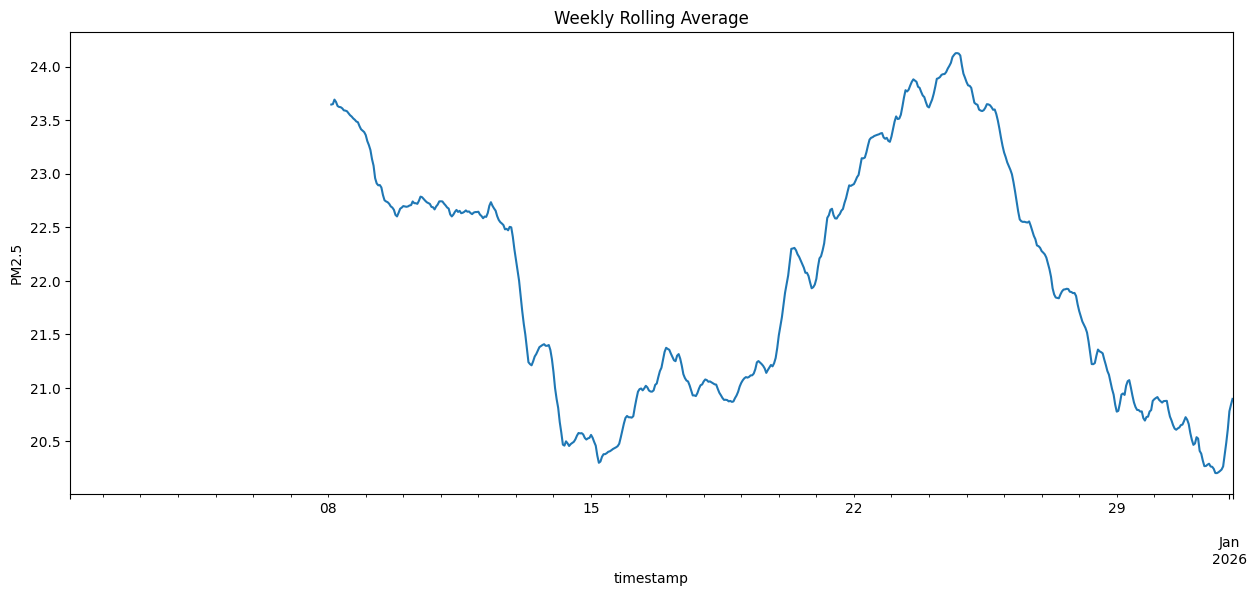

In [75]:
fig, ax = plt.subplots(figsize=(15, 6))
df["pm2.5"].rolling(168).mean().plot(ax=ax, ylabel="PM2.5", title="Weekly Rolling Average");

In [79]:
#Creating the Lag feature, basically the new column where the data is shifted by a lag of 1
df["pm2.5_L1"] = df["pm2.5"].shift(1)
df.dropna().head()

,pm2.5,pm2.5_L1
timestamp,,
2025-12-01 04:00:00+03:00,18.820000,24.144906
2025-12-01 05:00:00+03:00,28.562500,18.820000
2025-12-01 06:00:00+03:00,34.902381,28.562500
2025-12-01 07:00:00+03:00,32.240385,34.902381
2025-12-01 08:00:00+03:00,24.078571,32.240385


In [ ]:
#Now checking whether there is a relationship between the feature and the target.
df.corr()

,pm2.5,pm2.5_L1
pm2.5,1.00000,0.79145
pm2.5_L1,0.79145,1.00000


We can see there is strong positive correlation. Bacisally, there seems to be a relationship btn what happens at time step t, and timestep t-1.

In [87]:
#Checking for stationarity
result = adfuller(df["pm2.5"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic: -3.950047965422441
p-value: 0.0016958872199665347
Critical Values:
   1%: -3.4394
   5%: -2.8656
   10%: -2.5689


p-value = 0.0017 is well below 0.05

ADF Statistic = -3.95 — more negative than all three critical values (-3.44 at 1%, -2.87 at 5%, -2.57 at 10%)

This means we reject the null hypothesis of a unit root. The PM2.5 series has a constant mean and variance over time, so no differencing needed.

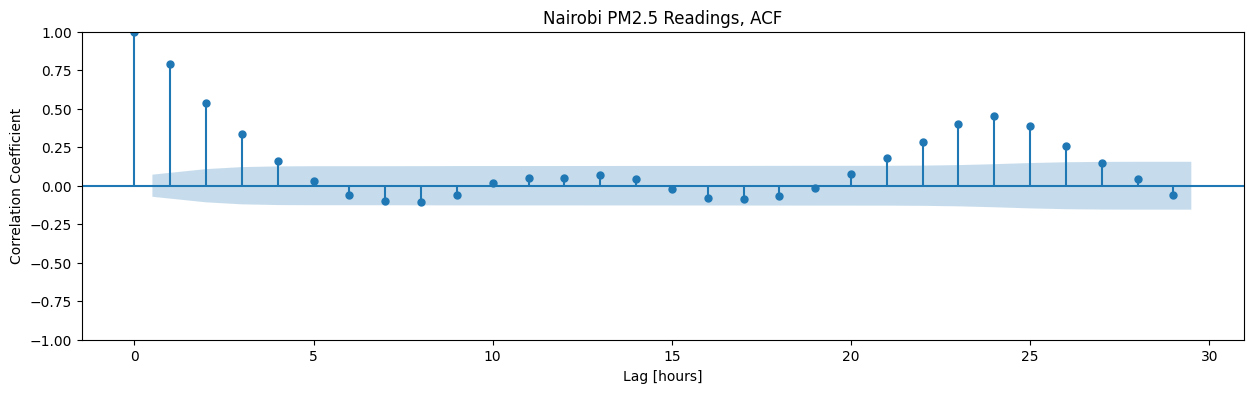

In [84]:
#ACF plot
fig, ax = plt.subplots(figsize=(15, 4))
plot_acf(df["pm2.5"], ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Nairobi PM2.5 Readings, ACF");

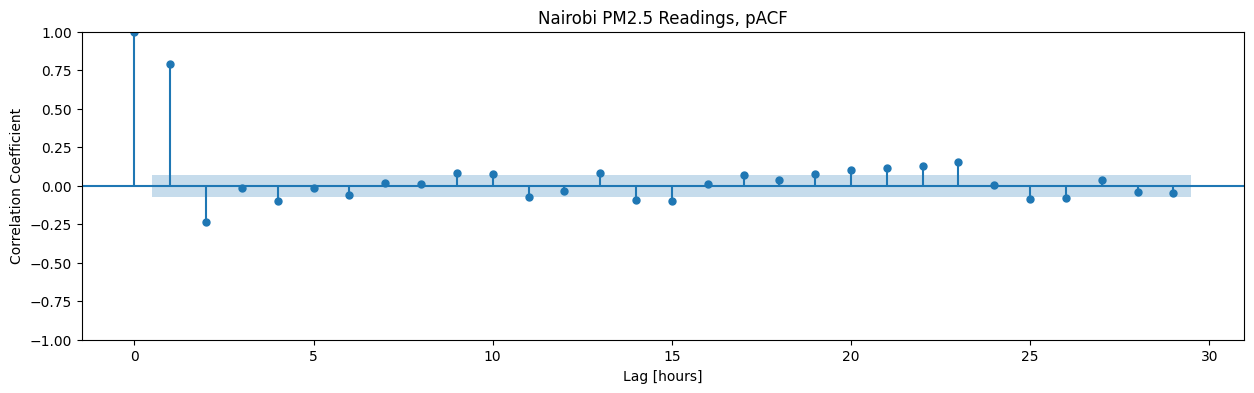

In [ ]:
#PACF plot
fig, ax = plt.subplots(figsize=(15, 4))
plot_pacf(df["pm2.5"], ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Nairobi PM2.5 Readings, pACF");

## Now Splitting the data before Modelling

In [ ]:
#The feature matrix and target vector
target = "pm2.5"
X = df[["pm2.5_L1"]]
y = df[target]

In [97]:
cutoff = int(len(X) * 0.8)

X_train, y_train = X.iloc[:cutoff], y.iloc[:cutoff]
X_test, y_test = X.iloc[cutoff:], y.iloc[cutoff:]

In [98]:
len(X_train) + len(X_test) == len(X)

True

### Modelling

In [101]:
#The baseline mae for the model
y_pred_baseline = [y_train.mean()] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean pm2.5:", round(y_train.mean(), 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean pm2.5: 22.59
Baseline MAE: 5.36


### i) Linear Model

In [103]:
#Build and train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [105]:
#Predicting and Evaluation
training_mae = mean_absolute_error(y_train, lr_model.predict(X_train))
test_mae = mean_absolute_error(y_test, lr_model.predict(X_test))

print("Training MAE:", round(training_mae, 2))
print("Test mae:", round(test_mae, 2))

Training MAE: 3.13
Test mae: 3.98


In [106]:
#Intercept and coefficient
intercept = lr_model.intercept_.round(2)
coefficient = lr_model.coef_.round(2)[0]
print(f"pm2.5 = {intercept} + ({coefficient} * pm2.5_L1)")

pm2.5 = 4.73 + (0.79 * pm2.5_L1)


In [107]:
df_pred_test = pd.DataFrame(
    {
    "y_test": y_test,
    "y_pred": lr_model.predict(X_test)
    }
)
df_pred_test.head()

,y_test,y_pred
timestamp,,
2025-12-25 22:00:00+03:00,18.247755,18.828347
2025-12-25 23:00:00+03:00,17.563000,19.149888
2025-12-26 00:00:00+03:00,17.426889,18.608832
2025-12-26 01:00:00+03:00,16.726444,18.501284
2025-12-26 02:00:00+03:00,15.833171,17.947832


In [ ]:
fig = px.line(df_pred_test, labels={"value":"pm2.5"})
fig.show();

### ii) AutoRegressive Model

In [110]:
ar_model = ARIMA(y_train, order=(2,0,0))
ar_result = ar_model.fit()
print(ar_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  pm2.5   No. Observations:                  594
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1664.084
Date:                Thu, 11 Jun 2026   AIC                           3336.168
Time:                        22:39:05   BIC                           3353.715
Sample:                    12-01-2025   HQIC                          3343.002
                         - 12-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.5401      0.668     33.754      0.000      21.231      23.849
ar.L1          0.9742      0.038     25.456      0.000       0.899       1.049
ar.L2         -0.2329      0.035     -6.585      0.0

In [122]:
print(f"Equation: pm2.5 = {const:.2f} + ({ar_l1:.4f} × L1) + ({ar_l2:.4f} × L2)")

Equation: pm2.5 = 22.55 + (1.4734 × L1) + (-0.6000 × L2)


In [117]:
ar_predictions = ar_result.forecast(steps=len(y_test))
mae_ar = mean_absolute_error(y_test, ar_predictions)
print("AR Model MAE:", round(mae_ar, 2))

AR Model MAE: 7.17


In [119]:
ar_predictions_wfv = []
history = list(y_train)

for i in range(len(y_test)):
    model = ARIMA(history, order=(2,0,0))
    result = model.fit()
    pred = result.forecast(steps=1)[0]
    ar_predictions_wfv.append(pred)
    history.append(y_test.iloc[i])

mae_ar_wfv = mean_absolute_error(y_test, ar_predictions_wfv)
print("AR Walk-forward MAE:", round(mae_ar_wfv, 2))

AR Walk-forward MAE: 3.84


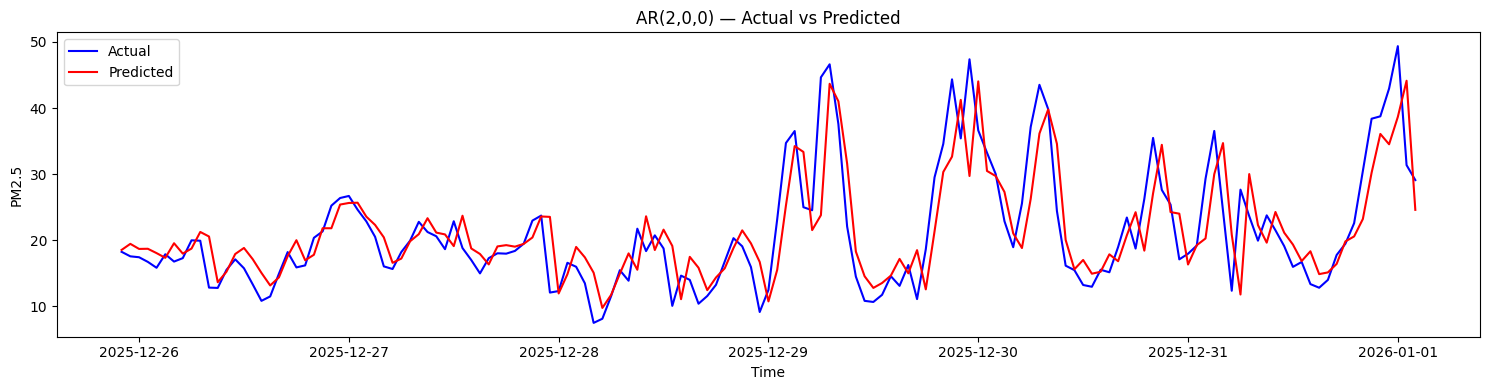

In [141]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(y_test.index, y_test, label="Actual", color="blue")
ax.plot(y_test.index, ar_predictions_wfv, label="Predicted", color="red")
ax.set_xlabel("Time")
ax.set_ylabel("PM2.5")
ax.set_title("AR(2,0,0) — Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.show();

### iii) ARIMA Model

In [121]:
arma_model = ARIMA(y_train, order=(2,0,2))
arma_result = arma_model.fit()
print(arma_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  pm2.5   No. Observations:                  594
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1660.580
Date:                Fri, 12 Jun 2026   AIC                           3333.161
Time:                        00:40:21   BIC                           3359.482
Sample:                    12-01-2025   HQIC                          3343.412
                         - 12-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.5484      0.554     40.666      0.000      21.462      23.635
ar.L1          1.4734      0.144     10.243      0.000       1.191       1.755
ar.L2         -0.6000      0.094     -6.408      0.0

In [123]:
print(f"Equation: pm2.5 = {const:.2f} + ({ar_l1:.4f} × L1) + ({ar_l2:.4f} × L2) + ({ma_l1:.4f} × e1) + ({ma_l2:.4f} × e2)")

Equation: pm2.5 = 22.55 + (1.4734 × L1) + (-0.6000 × L2) + (-0.5097 × e1) + (-0.0908 × e2)


In [124]:
arma_predictions_wfv = []
history = list(y_train)

for i in range(len(y_test)):
    model = ARIMA(history, order=(2,0,2))
    result = model.fit()
    pred = result.forecast(steps=1)[0]
    arma_predictions_wfv.append(pred)
    history.append(y_test.iloc[i])

mae_arma_wfv = mean_absolute_error(y_test, arma_predictions_wfv)
print("ARMA Walk-forward MAE:", round(mae_arma_wfv, 2))

ARMA Walk-forward MAE: 3.85


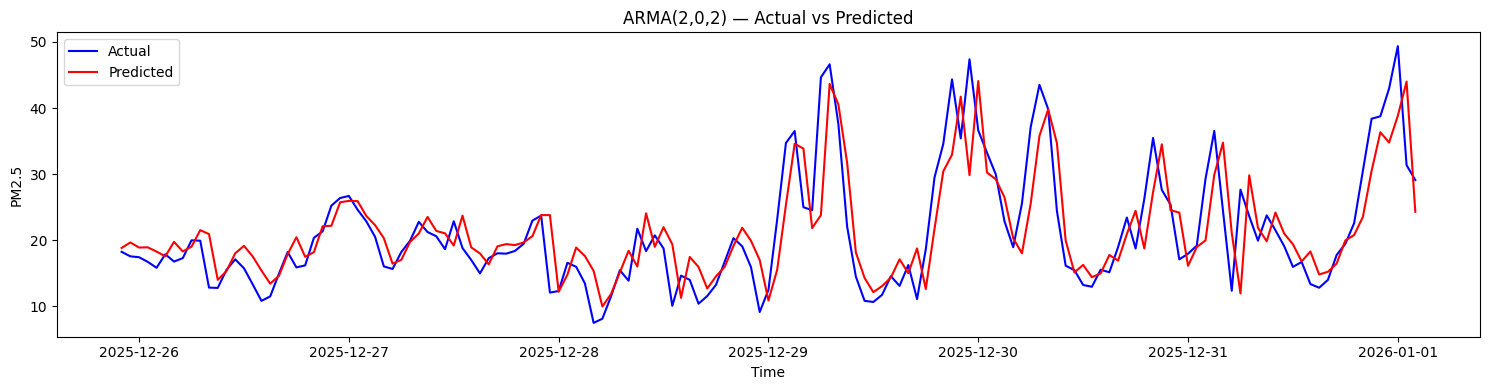

In [142]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(y_test.index, y_test, label="Actual", color="blue")
ax.plot(y_test.index, arma_predictions_wfv, label="Predicted", color="red")
ax.set_xlabel("Time")
ax.set_ylabel("PM2.5")
ax.set_title("ARMA(2,0,2) — Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.show();

### iv) SARIMA Model

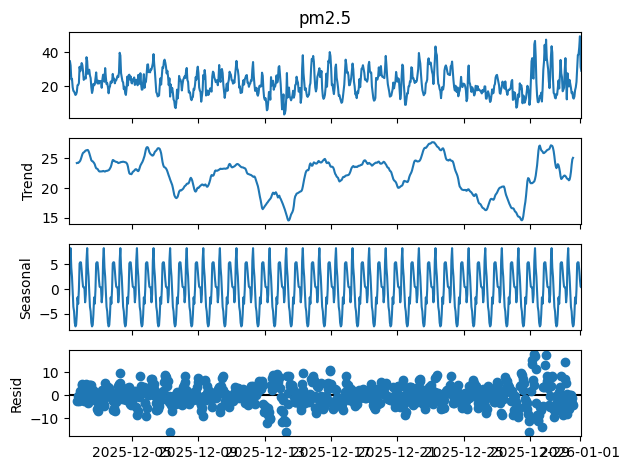

In [127]:
decomposition = seasonal_decompose(df["pm2.5"], model="additive", period=24)
decomposition.plot()
plt.tight_layout()
plt.show();

In [133]:
sarima_model = SARIMAX(y_train, 
                       order=(2,0,2), 
                       seasonal_order=(1,0,1,24))
sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                pm2.5   No. Observations:                  594
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 24)   Log Likelihood               -1577.040
Date:                              Fri, 12 Jun 2026   AIC                           3168.080
Time:                                      01:29:02   BIC                           3198.788
Sample:                                  12-01-2025   HQIC                          3180.040
                                       - 12-25-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6340      0.060     27.395      0.000       1.517       1.751
ar.L2         -0.63

In [136]:
ar_l1 = sarima_result.params["ar.L1"]
ar_l2 = sarima_result.params["ar.L2"]
ma_l1 = sarima_result.params["ma.L1"]
ma_l2 = sarima_result.params["ma.L2"]
ar_s = sarima_result.params["ar.S.L24"]
ma_s = sarima_result.params["ma.S.L24"]

print(f"Equation: pm2.5 = ({ar_l1:.4f} × L1) + ({ar_l2:.4f} × L2) + ({ma_l1:.4f} × e1) + ({ma_l2:.4f} × e2) + ({ar_s:.4f} × SL24) + ({ma_s:.4f} × Se1)")

Equation: pm2.5 = (1.6340 × L1) + (-0.6391 × L2) + (-0.7972 × e1) + (-0.1231 × e2) + (0.9984 × SL24) + (-0.9489 × Se1)


In [137]:
sarima_predictions_wfv = []
history = list(y_train)

for i in range(len(y_test)):
    model = SARIMAX(history, order=(2,0,2), seasonal_order=(1,0,1,24))
    result = model.fit(disp=False)
    pred = result.forecast(steps=1)[0]
    sarima_predictions_wfv.append(pred)
    history.append(y_test.iloc[i])

mae_sarima_wfv = mean_absolute_error(y_test, sarima_predictions_wfv)
print("SARIMA Walk-forward MAE:", round(mae_sarima_wfv, 2))

c:\Users\user\Downloads\Machine Learning 2\env1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\user\Downloads\Machine Learning 2\env1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\user\Downloads\Machine Learning 2\env1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\user\Downloads\Machine Learning 2\env1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users

SARIMA Walk-forward MAE: 3.59


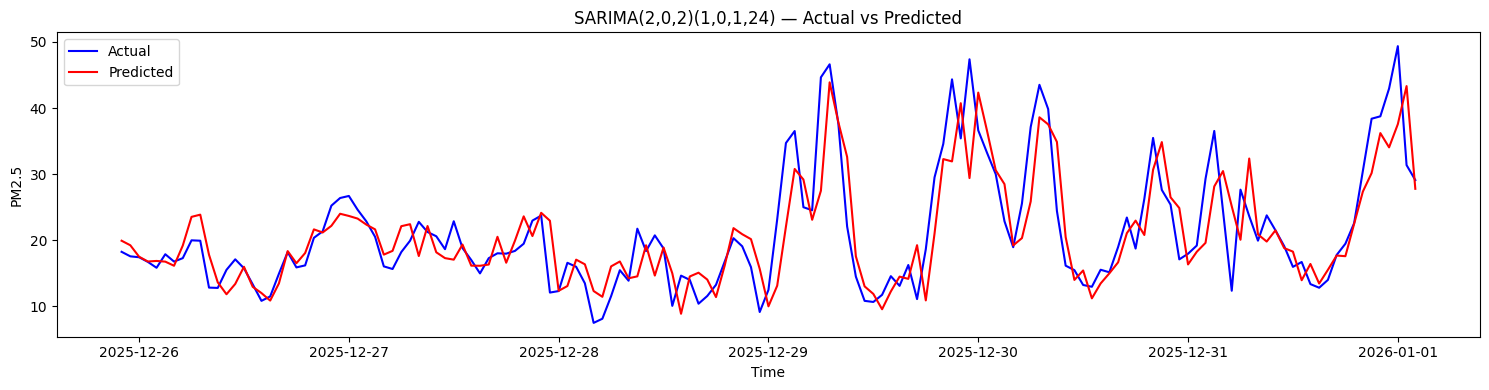

In [143]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(y_test.index, y_test, label="Actual", color="blue")
ax.plot(y_test.index, sarima_predictions_wfv, label="Predicted", color="red")
ax.set_xlabel("Time")
ax.set_ylabel("PM2.5")
ax.set_title("SARIMA(2,0,2)(1,0,1,24) — Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.show();

### V) MAE Comparison

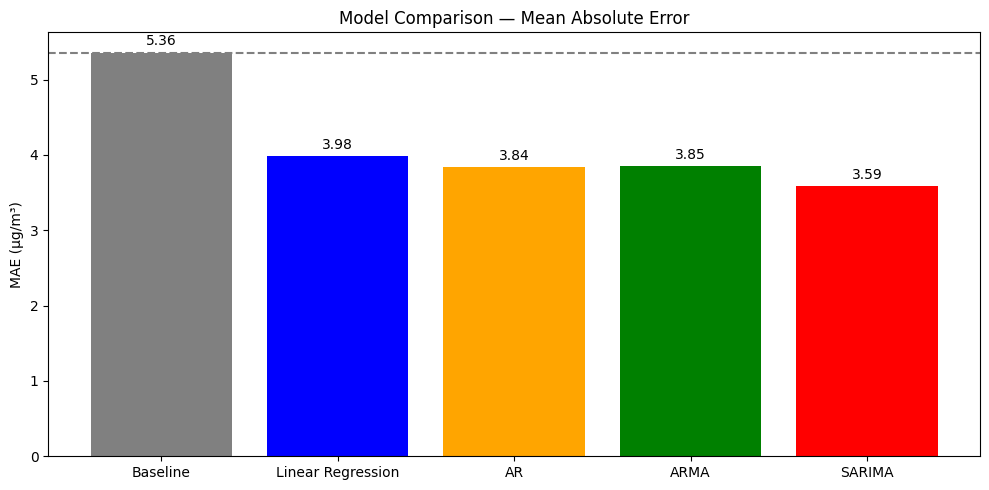

In [144]:
models = ["Baseline", "Linear Regression", "AR", "ARMA", "SARIMA"]
maes = [5.36, 3.98, 3.84, 3.85, 3.59]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models, maes, color=["gray", "blue", "orange", "green", "red"])
ax.axhline(y=5.36, color="gray", linestyle="--", label="Baseline")
ax.set_ylabel("MAE (µg/m³)")
ax.set_title("Model Comparison — Mean Absolute Error")
ax.bar_label(bars, fmt="%.2f", padding=3)
plt.tight_layout()
plt.show()

### vi)  EPA threshold exceedances for Nairobi

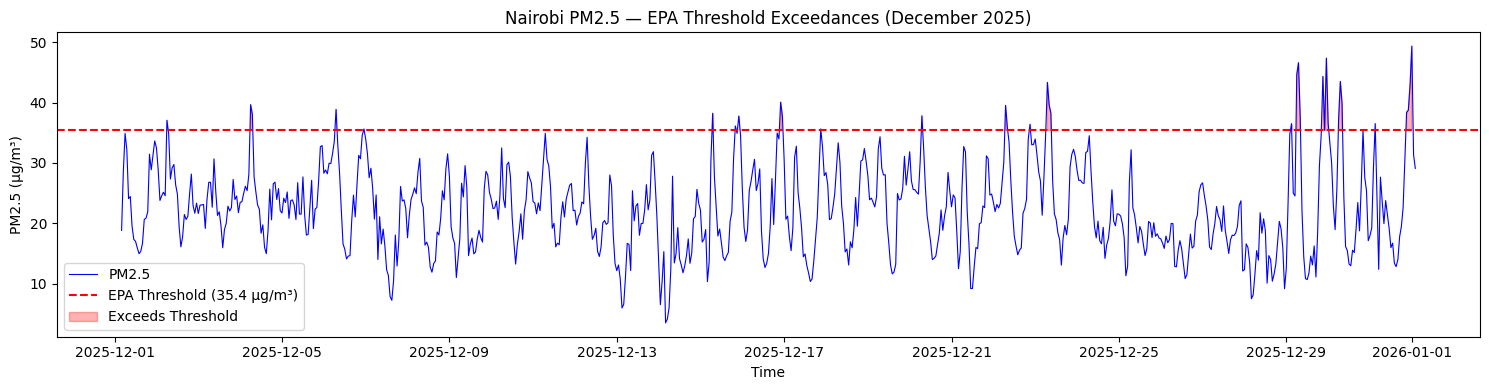

Total hours: 743
Hours exceeding EPA threshold: 35
Percentage: 4.71%


In [ ]:
#Define EPA threshold
epa_threshold = 35.4

#Create exceedance column
df["exceeds_epa"] = df["pm2.5"] > epa_threshold

#Plot
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df.index, df["pm2.5"], color="blue", linewidth=0.8, label="PM2.5")
ax.axhline(y=epa_threshold, color="red", linestyle="--", linewidth=1.5, label="EPA Threshold (35.4 µg/m³)")
ax.fill_between(df.index, df["pm2.5"], epa_threshold,
                where=df["pm2.5"] > epa_threshold,
                color="red", alpha=0.3, label="Exceeds Threshold")
ax.set_xlabel("Time")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Nairobi PM2.5 — EPA Threshold Exceedances (December 2025)")
ax.legend()
plt.tight_layout()
plt.show()

#Print summary
total_hours = len(df)
exceeded_hours = df["exceeds_epa"].sum()
print(f"Total hours: {total_hours}")
print(f"Hours exceeding EPA threshold: {exceeded_hours}")
print(f"Percentage: {round((exceeded_hours/total_hours)*100, 2)}%")

### Saving the results to csv

In [146]:
import os
os.makedirs("data", exist_ok=True)

# Save hourly data
df.to_csv("data/df_hourly.csv")

# Save all predictions
df_results = pd.DataFrame({
    "actual": y_test.values,
    "linear_regression": y_pred_lr,
    "ar": ar_predictions_wfv,
    "arma": arma_predictions_wfv,
    "sarima": sarima_predictions_wfv
}, index=y_test.index)

df_results.to_csv("data/predictions.csv")

# Save MAE scores
df_mae = pd.DataFrame({
    "model": ["Baseline", "Linear Regression", "AR", "ARMA", "SARIMA"],
    "mae": [5.36, 3.98, 3.84, 3.85, 3.59]
})
df_mae.to_csv("data/mae_scores.csv", index=False)
